Part 1
Slope: 0.9500000000000001, Intercept: 0.5900000000000001


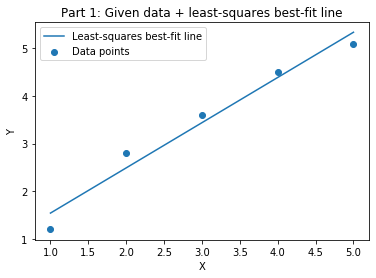


Part 2
Slope: 0.6181359294678656, Intercept: 1.6671610185904453


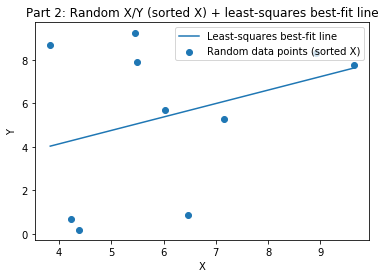


Part 3
Original line: y = 2.5x + -0.4
Least-squares fit: y = 2.7860276995246496x + -0.5744111237863518
Largest |residual| at index 98: x=0.98, y=1.0557, residual=-1.1002
Smallest |residual| at index 54: x=0.54, y=0.9331, residual=0.0031


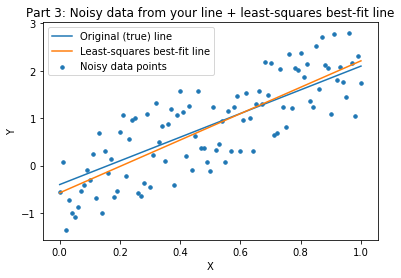

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# ChatGPT Used to help generate nicer plots, and fix why they were not showing up with the line below
%matplotlib inline

def least_squares_line_fit(X, Y):
    A = np.vstack([X, np.ones(len(X))]).T  # design matrix [x, 1]
    m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
    return m, c


X = np.array([1, 2, 3, 4, 5])
Y = np.array([1.2, 2.8, 3.6, 4.5, 5.1])

m, c = least_squares_line_fit(X, Y)
print("Part 1")
print(f"Slope: {m}, Intercept: {c}")

Y_fit = m * X + c

plt.figure()
plt.scatter(X, Y, label="Data points")
plt.plot(X, Y_fit, label="Least-squares best-fit line")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Part 1: Given data + least-squares best-fit line")
plt.legend()
plt.show()


np.random.seed(0)

n = 10
X_rand = np.random.rand(n) * 10          # random X in [0, 10)
Y_rand = np.random.rand(n) * 10          # random Y in [0, 10)

order = np.argsort(X_rand)
X2 = X_rand[order]
Y2 = Y_rand[order]

m2, c2 = least_squares_line_fit(X2, Y2)
print("\nPart 2")
print(f"Slope: {m2}, Intercept: {c2}")

Y2_fit = m2 * X2 + c2

plt.figure()
plt.scatter(X2, Y2, label="Random data points (sorted X)")
plt.plot(X2, Y2_fit, label="Least-squares best-fit line")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Part 2: Random X/Y (sorted X) + least-squares best-fit line")
plt.legend()
plt.show()


np.random.seed(1) 

m_true = 2.5
b_true = -0.4

X3 = np.arange(0, 1.01, 0.01) 

noise = (2 * np.random.rand(len(X3)) - 1) 
Y3 = m_true * X3 + b_true + noise

m3, c3 = least_squares_line_fit(X3, Y3)
print("\nPart 3")
print(f"Original line: y = {m_true}x + {b_true}")
print(f"Least-squares fit: y = {m3}x + {c3}")

Y3_fit = m3 * X3 + c3
residuals = Y3 - Y3_fit

i_max = np.argmax(np.abs(residuals))
i_min = np.argmin(np.abs(residuals))

print(f"Largest |residual| at index {i_max}: x={X3[i_max]:.2f}, y={Y3[i_max]:.4f}, residual={residuals[i_max]:.4f}")
print(f"Smallest |residual| at index {i_min}: x={X3[i_min]:.2f}, y={Y3[i_min]:.4f}, residual={residuals[i_min]:.4f}")

plt.figure()
plt.scatter(X3, Y3, s=12, label="Noisy data points")
plt.plot(X3, m_true * X3 + b_true, label="Original line")
plt.plot(X3, Y3_fit, label="Least-squares best-fit line")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Part 3: Noisy data from your line + least-squares best-fit line")
plt.legend()
plt.show()